# EDA

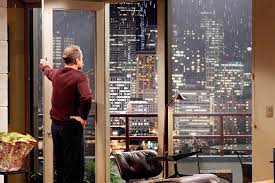

In [ ]:
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [44]:
warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)


Load the data.
Make a copy so the original is always there for comparison.

In [45]:
df_original = pd.read_csv("data/eda_clean.csv")
df = df_original.copy()

Customer is:
Nicole Johnson who wants to buy a home in a lively, central neighborhood, middle price range, right timing (within a year).
So let's take this appart:
1. lively
2. central
3. middle price range
4. right timing within a year

## 1. Lively

Since there is no way to from the data how lively an area is, we assume that lively and central satisfy the same need. The more central a location the more likely that there is a lot going on.

*ASSUMPTION #1*: Central satisfies lively.


## 2. Central

In central areas the density of the houses usually increases. This means there is not much property left other than the house itself. This translates to a *footage of the lot / house footprint* close to 1. Since if the lot is much bigger than the house footprint itself this would push houses apart.

*ASSUMPTION #2*: "Central" correlates with a low sqft_lot / footprint ratio.

But how do we get the footprint of the house, since there is no such data column?

`sqft_living` adds up every floor, also the basements. But basements are regularly smaller than the house footprint in the US. 

*ASSUMPTION #3*: Basements have smaller footprint than the house itself.

So let's take `sqft_above / floors` as a good `footprint` estimate, since it excludes the basement, which isn't a floor. About 10% of houses have "half floors" (1.5/2.5/3.5, a partial upper floor), so this slightly *underestimates* the true footprint — but that's the best we can do since there is no per-floor area in the data.

*ASSUMPTION #4*: `sqft_above / floors` is a good estimate of the house's footprint.

We can't apply the same calculation with the "next 15 neighbors" columns, because those are already pre-aggregated and the dataset doesn't give us each neighbor's `floors` count.

So if our assumption turns out true, we will need to create our own version o the neighbor's footage ratio.

Let's clean the data before going into footage comparisons. Deleting only the upper outliers. The lower ones we are still interested in, since it might point to a high house density -> more central.

In [70]:
def remove_upper_outliers(df: pd.DataFrame, col_name: str) -> pd.DataFrame:
    q_25 = df[col_name].quantile(0.25)
    q_75 = df[col_name].quantile(0.75)
    iqr = q_75 - q_25

    return df[df[col_name] <= q_75 + (1.5 * iqr)]

In [75]:
df["sqft_footprint"] = df["sqft_above"] / df["floors"]

df = remove_upper_outliers(df, "sqft_lot")
df = remove_upper_outliers(df, "sqft_basement")
df = remove_upper_outliers(df, "sqft_footprint")

print(f"We have now {df_original.shape[0] - df.shape[0]} less entries")

We have now 4082 less entries


### Test Assumptions #3 & #4

Meaning: are basements really smaller than the house's footprint, is `sqft_above / floors` a good estimate of the house's footprint?

We plot `sqft_basement` against the footprint directly. 
Since for single-floor houses the `sqft_above` should exactly match the footprint area we can assume this is a pretty precise comparison.

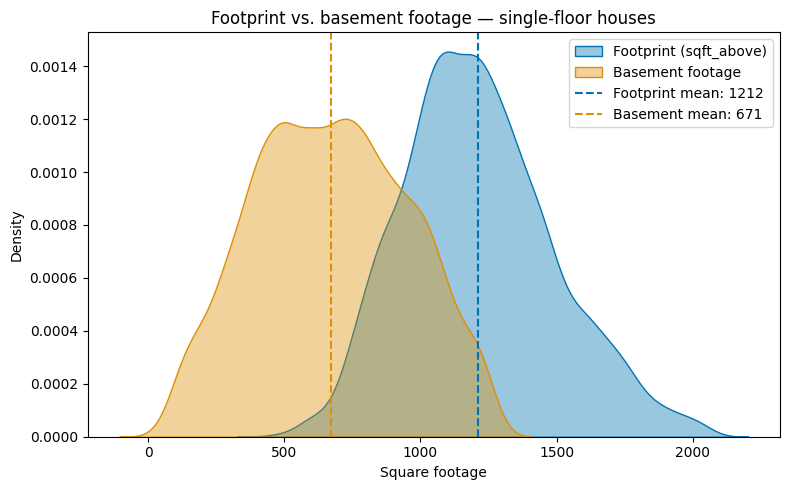

Sample Size:  4274


In [81]:
single_floor_with_basement = df[(df["floors"] == 1) & (df["sqft_basement"] > 0)]

footprint_mean = single_floor_with_basement["sqft_above"].mean()
basement_mean = single_floor_with_basement["sqft_basement"].mean()

palette = sns.color_palette("colorblind")
fig, ax = plt.subplots()
sns.kdeplot(
    single_floor_with_basement["sqft_above"],
    fill=True,
    alpha=0.4,
    color=palette[0],
    label="Footprint (sqft_above)",
    ax=ax,
)
sns.kdeplot(
    single_floor_with_basement["sqft_basement"],
    fill=True,
    alpha=0.4,
    color=palette[1],
    label="Basement footage",
    ax=ax,
)
ax.axvline(
    footprint_mean,
    color=palette[0],
    linestyle="--",
    linewidth=1.5,
    label=f"Footprint mean: {footprint_mean:.0f}",
)
ax.axvline(
    basement_mean,
    color=palette[1],
    linestyle="--",
    linewidth=1.5,
    label=f"Basement mean: {basement_mean:.0f}",
)
ax.set_title("Footprint vs. basement footage — single-floor houses")
ax.set_xlabel("Square footage")
ax.legend()
plt.tight_layout()
plt.show()

print("Sample Size: ", single_floor_with_basement.shape[0])

For multi-floor houses we use our estimation `sqft_footprint` to see if it bahaves similarly.

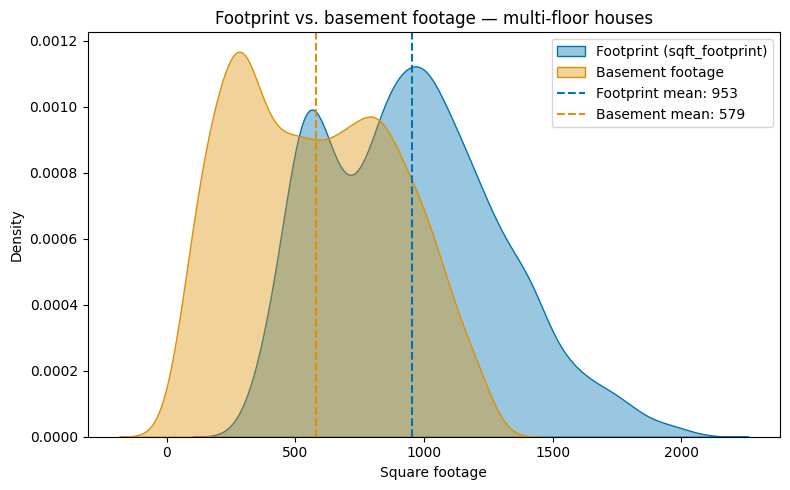

Sample Size:  2417


In [80]:
multi_floor_with_basement = df[(df["floors"] > 1) & (df["sqft_basement"] > 0)]

footprint_mean = multi_floor_with_basement["sqft_footprint"].mean()
basement_mean = multi_floor_with_basement["sqft_basement"].mean()

palette = sns.color_palette("colorblind")
fig, ax = plt.subplots()
sns.kdeplot(
    multi_floor_with_basement["sqft_footprint"],
    fill=True,
    alpha=0.4,
    color=palette[0],
    label="Footprint (sqft_footprint)",
    ax=ax,
)
sns.kdeplot(
    multi_floor_with_basement["sqft_basement"],
    fill=True,
    alpha=0.4,
    color=palette[1],
    label="Basement footage",
    ax=ax,
)
ax.axvline(
    footprint_mean,
    color=palette[0],
    linestyle="--",
    linewidth=1.5,
    label=f"Footprint mean: {footprint_mean:.0f}",
)
ax.axvline(
    basement_mean,
    color=palette[1],
    linestyle="--",
    linewidth=1.5,
    label=f"Basement mean: {basement_mean:.0f}",
)
ax.set_title("Footprint vs. basement footage — multi-floor houses")
ax.set_xlabel("Square footage")
ax.legend()
plt.tight_layout()
plt.show()
print("Sample Size: ", multi_floor_with_basement.shape[0])

#### Conclusion

Looking at the one-floor data we see that the basements are definitely probable to be smaller than the house footprint.

Looking at our multi-floor data we see roughly the same distribution. We already expected our footprint estimate to be slightly understimated, which could lead to the slightly closer means in the second graph.

All in all it makes our assumptions #3 and #4 reasonable.

### Test Assumption #2

Meaning, does a low lot to footprint ratio correlate with densly populated areas?

First, let's create the new entry for the ratio and scattorplot it to see if our assumption is sound.

In [82]:
df["lot_to_footprint_ratio"] = df["sqft_lot"] / df["sqft_footprint"]

In [83]:
# Bounds for the geographic scatterplots below,
# after first plots this is where something interesting is happening for our customer
MAP_LONG_MIN, MAP_LONG_MAX = -122.5, -121.6
MAP_LAT_MIN, MAP_LAT_MAX = 47.1, 47.8

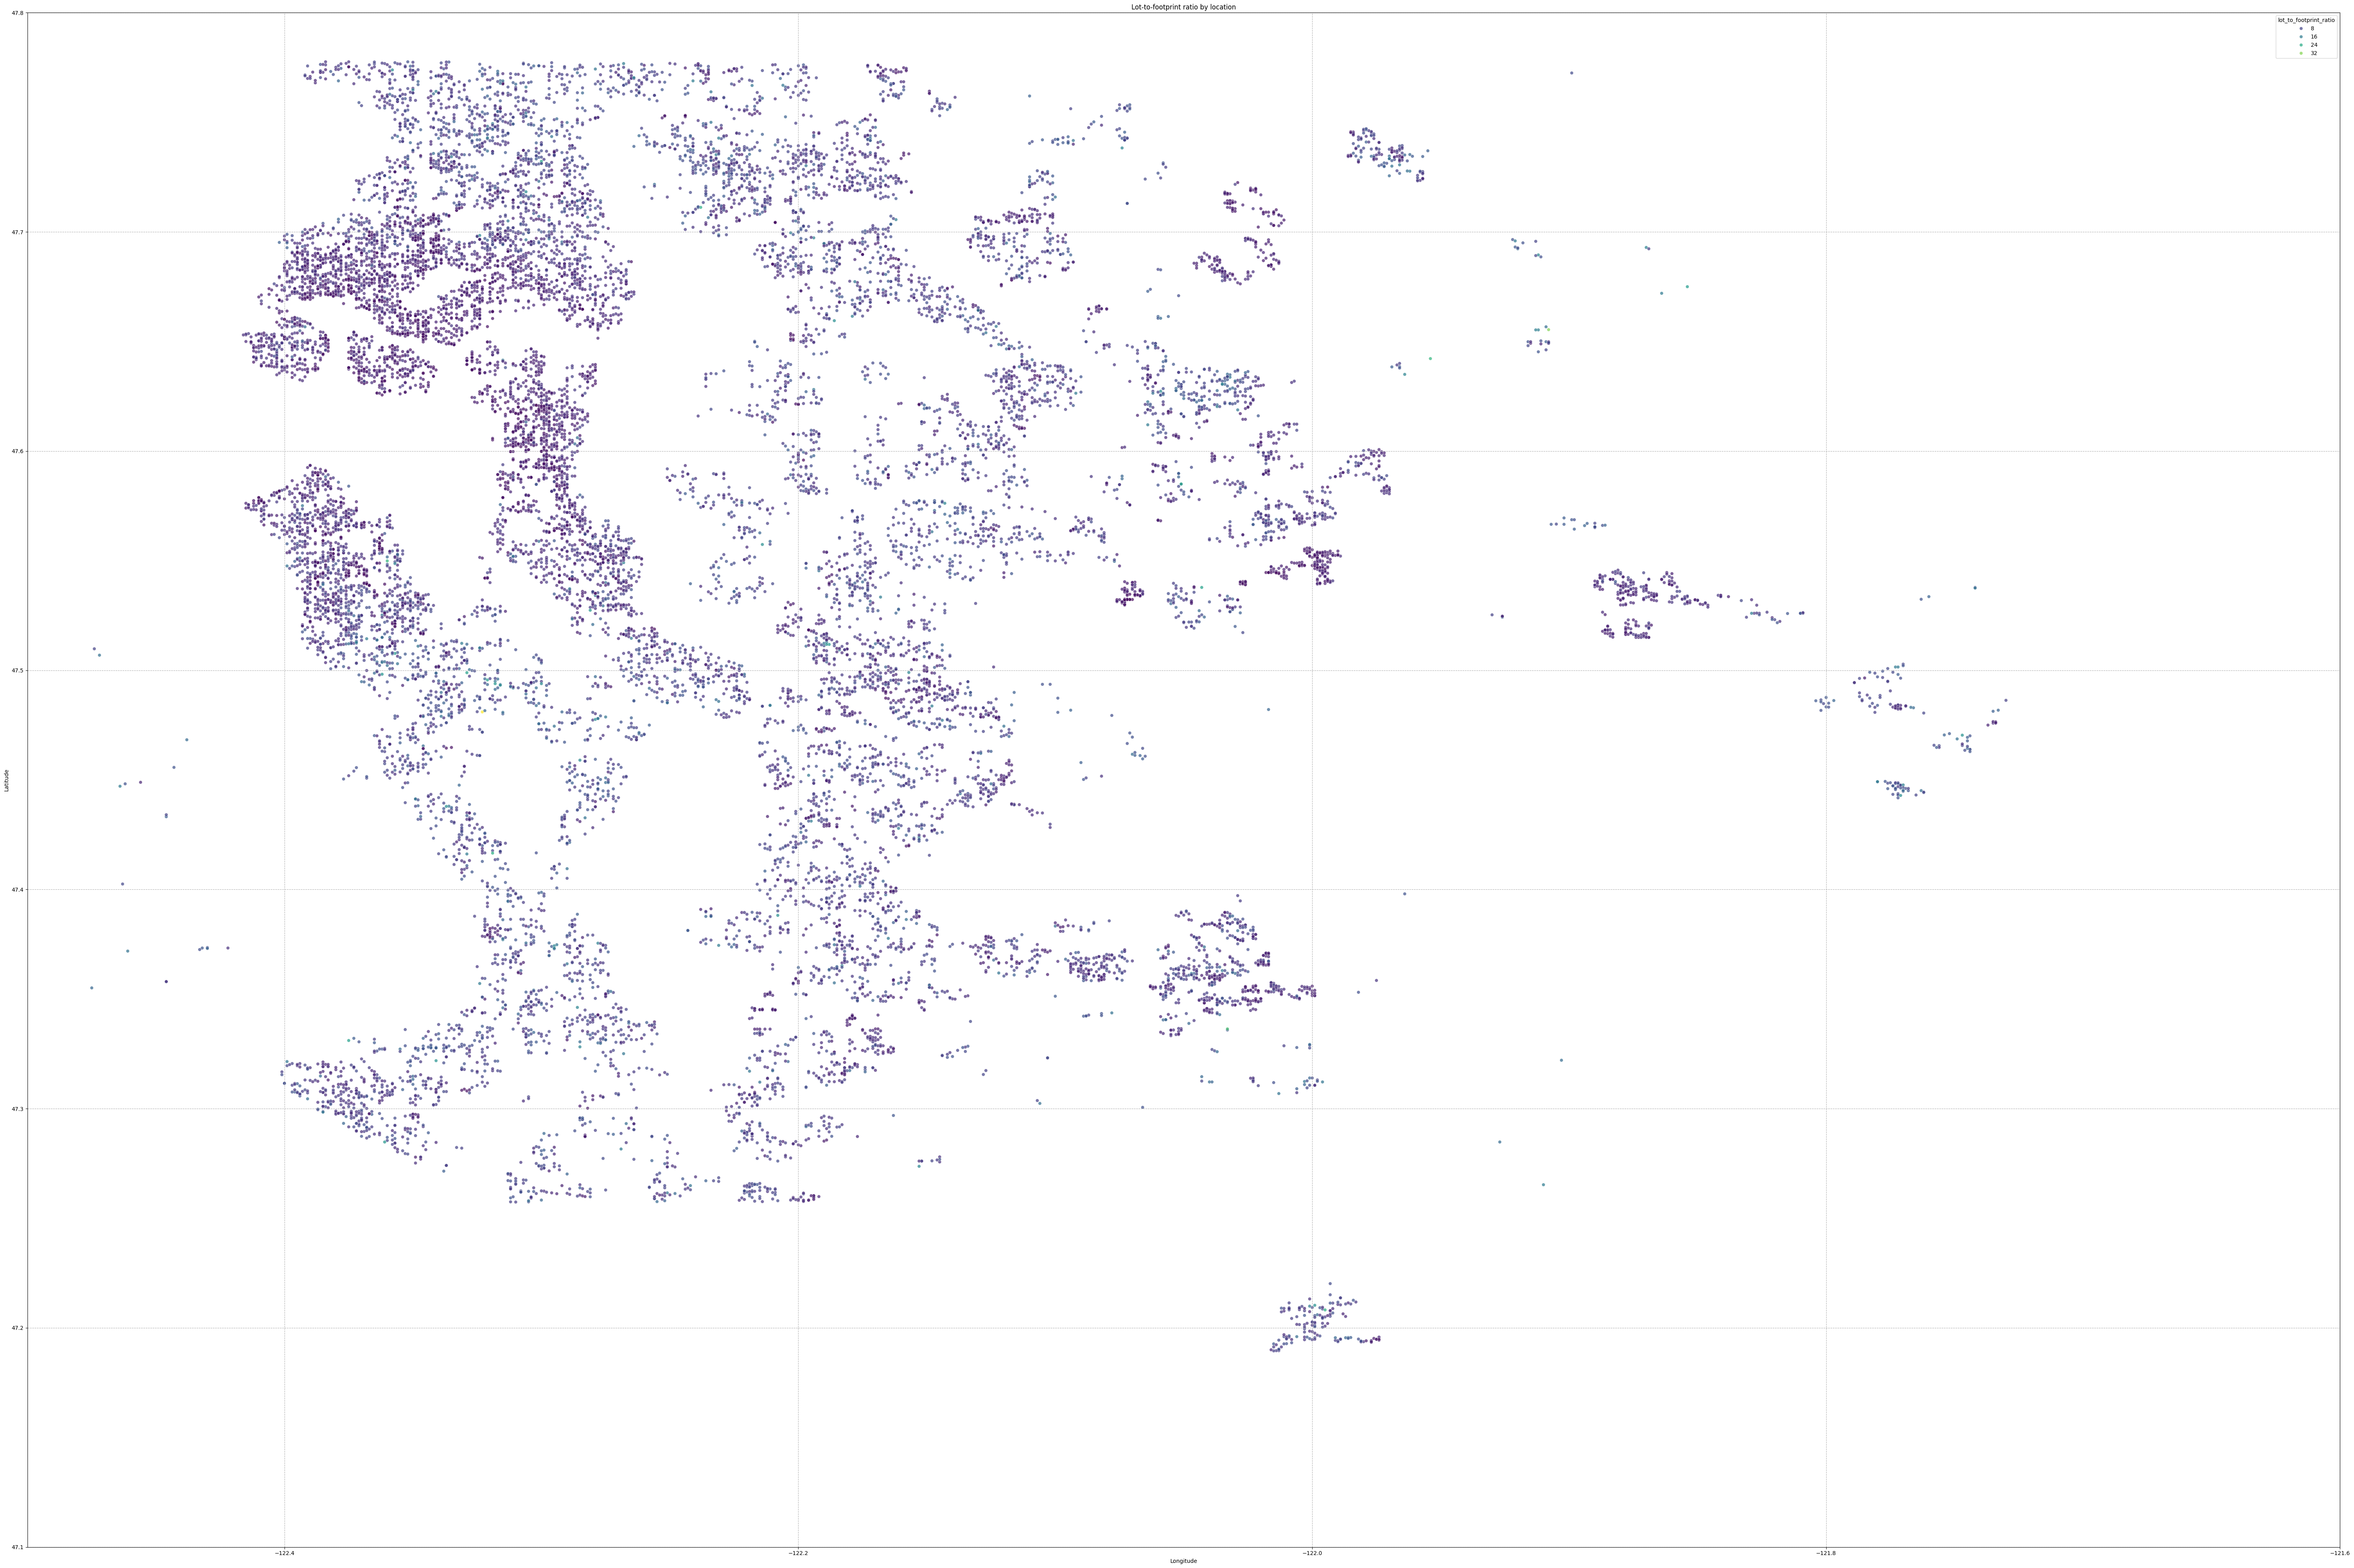

In [95]:
fig, ax = plt.subplots(figsize=(60, 40))

sns.scatterplot(
    data=df,
    x="long",
    y="lat",
    hue="lot_to_footprint_ratio",
    palette="viridis",
    alpha=0.7,
    ax=ax,
)

ax.set_title("Lot-to-footprint ratio by location")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(MAP_LONG_MIN, MAP_LONG_MAX)
ax.set_ylim(MAP_LAT_MIN, MAP_LAT_MAX)
ax.grid(True, linestyle="--")
plt.tight_layout()
plt.show()

### Validating the clustering statistically

The scatterplot hints that `lot_to_footprint_ratio` clusters geographically, but that's hard to judge by eye. We use **Moran's I** to test this properly: a statistic that tells us whether nearby houses have more similar ratios than pure chance would predict. We use the `libpysal`/`esda` implementations (the standard PySAL toolkit).

**Choosing k:** For the K-Nearest Neighbors alghorithm we need to select a meaningful `k`. Looking at the dataset we see that 15 neighbors is assumed to be a meaningful value (see `sqft_living15`, `sqft_lot15`). So we use `k=15` here too, to stay consistent with that existing convention rather than picking a number out of thin air.

In [88]:
from libpysal.weights import KNN
from esda.moran import Moran, Moran_Local


def global_moran(
    df: pd.DataFrame,
    value_col: str,
    lat_col: str = "lat",
    long_col: str = "long",
    k: int = 15,
) -> Moran:
    coords = df[[long_col, lat_col]].to_numpy()
    w = KNN.from_array(coords, k=k)
    w.transform = "r"

    return Moran(df[value_col].to_numpy(), w)


def local_moran(
    df: pd.DataFrame,
    value_col: str,
    lat_col: str = "lat",
    long_col: str = "long",
    k: int = 15,
    seed: int = 42,
) -> Moran_Local:
    coords = df[[long_col, lat_col]].to_numpy()
    w = KNN.from_array(coords, k=k)
    w.transform = "r"

    return Moran_Local(df[value_col].to_numpy(), w, seed=seed)

First, the global check: is there any spatial clustering at all? If this comes back non-significant there's no point looking for individual clusters.

In [94]:
moran = global_moran(df, "lot_to_footprint_ratio")

print(f"Moran's I: {moran.I:.3f}")
print(f"p-value (permutation-based): {moran.p_sim:.4f}")

Moran's I: 0.360
p-value (permutation-based): 0.0010


Moran's I is positive and significant, so `lot_to_footprint_ratio` does cluster geographically rather than being spread randomly. 

Now let's find *where*, and whether there's more than one cluster, with Local Moran's I (LISA). Each house gets its own cluster label: 
- high-high and low-low are genuine clusters (a house surrounded by similarly-ranked neighbors).
- high-low and low-high are spatial outliers (a house surrounded by dissimilar neighbors). 

Low-Low is the pattern we actually want: a house with a low lot-to-footprint ratio that's also surrounded by similarly dense neighbors.

Only points with p < 0.05 are labeled, the rest are "not significant". 

We fix a `seed` for reproducible results — checked across several seeds, the low-low cluster size only varies by about 3% (~4,800-5,000 houses), so the choice of seed doesn't change the conclusion.

lisa_cluster
not significant    8120
low-low            4613
high-high          3191
low-high           1061
high-low            530
Name: count, dtype: int64


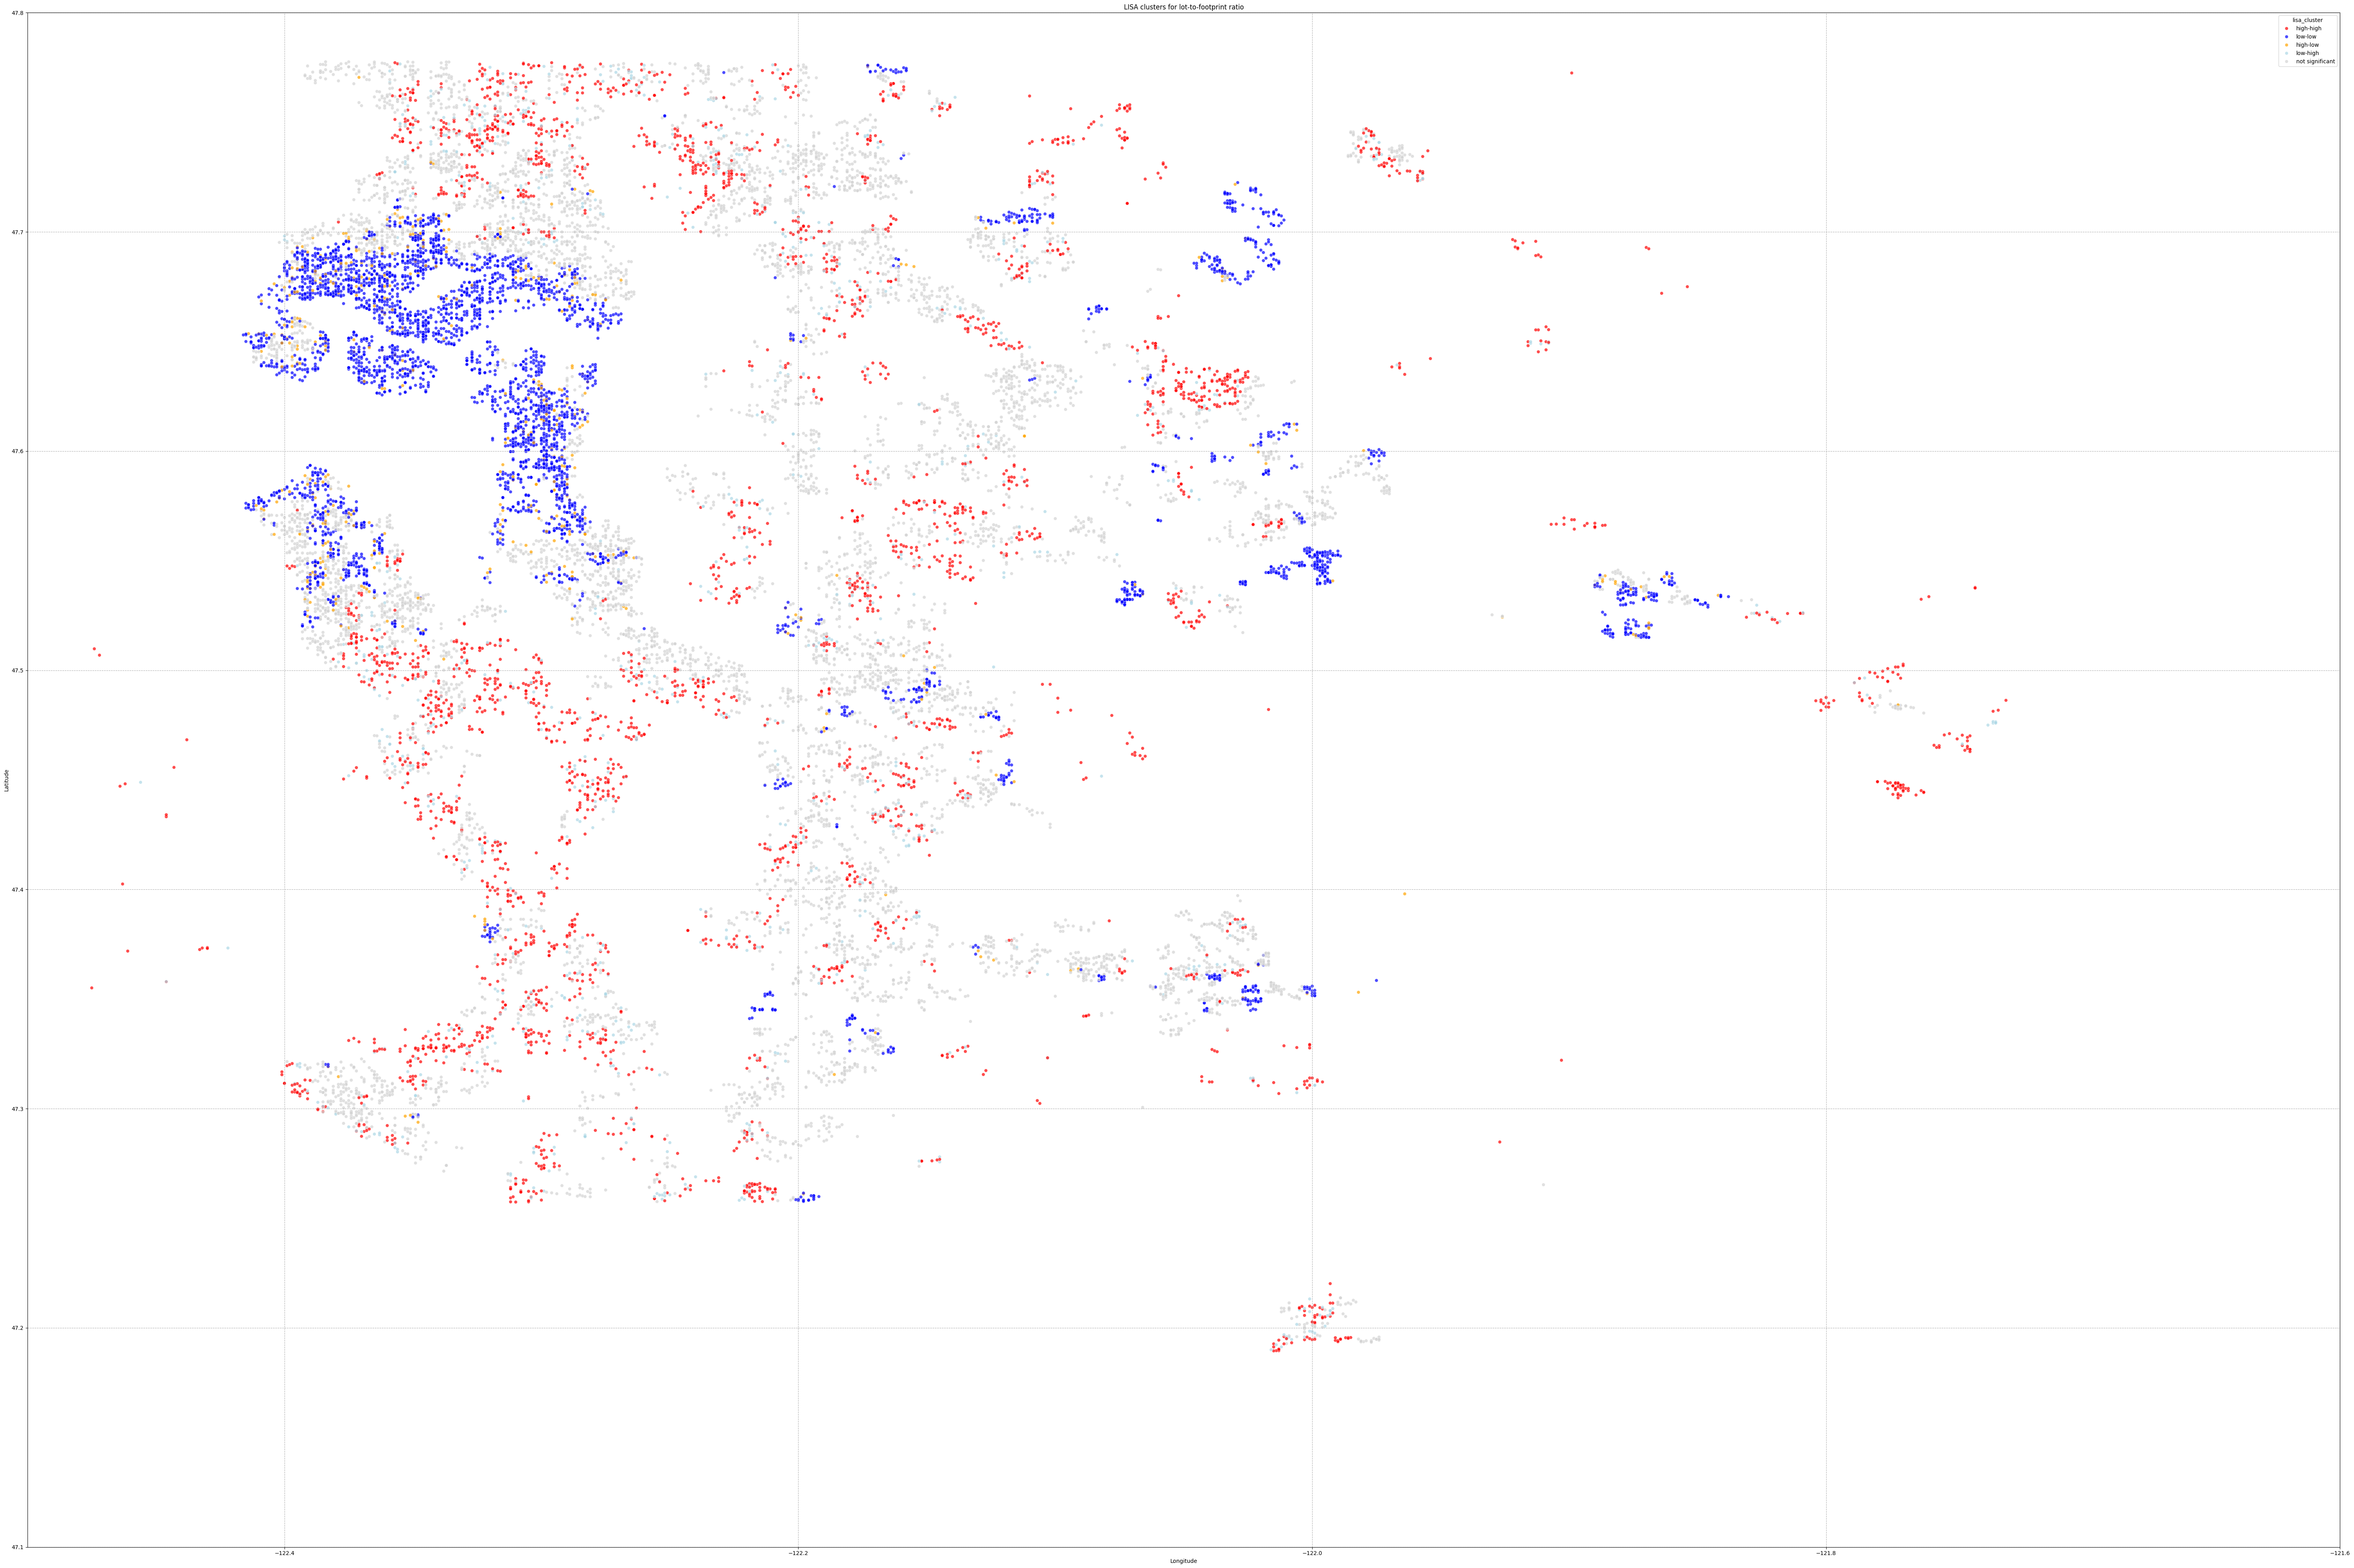

In [93]:
lisa = local_moran(df, "lot_to_footprint_ratio")

cluster_labels = {1: "high-high", 2: "low-high", 3: "low-low", 4: "high-low"}
significant = lisa.p_sim < 0.05

df["lisa_cluster"] = "not significant"
for code, label in cluster_labels.items():
    df.loc[significant & (lisa.q == code), "lisa_cluster"] = label

print(df["lisa_cluster"].value_counts())

fig, ax = plt.subplots(figsize=(60, 40))
sns.scatterplot(
    data=df,
    x="long",
    y="lat",
    hue="lisa_cluster",
    hue_order=["high-high", "low-low", "high-low", "low-high", "not significant"],
    palette={
        "high-high": "red",
        "low-low": "blue",
        "high-low": "orange",
        "low-high": "lightblue",
        "not significant": "lightgrey",
    },
    alpha=0.7,
    ax=ax,
)
ax.set_title("LISA clusters for lot-to-footprint ratio")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(MAP_LONG_MIN, MAP_LONG_MAX)
ax.set_ylim(MAP_LAT_MIN, MAP_LAT_MAX)
ax.grid(True, linestyle="--")
plt.tight_layout()
plt.show()

Looking at the plot (and comparing it with a map of King County) we can see that there is a big clustering arround Seatle, which leads us to the conclusion that our assumption that "Central" neighborhoods are the houses in a Low-Low LISA cluster is reasonable.

In [92]:
df_central = df[df["lisa_cluster"] == "low-low"]

print(f"{df_central.shape[0]} of {df.shape[0]} houses are in a central (low-low) cluster")

4613 of 17515 houses are in a central (low-low) cluster
